In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]

        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

Simple LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


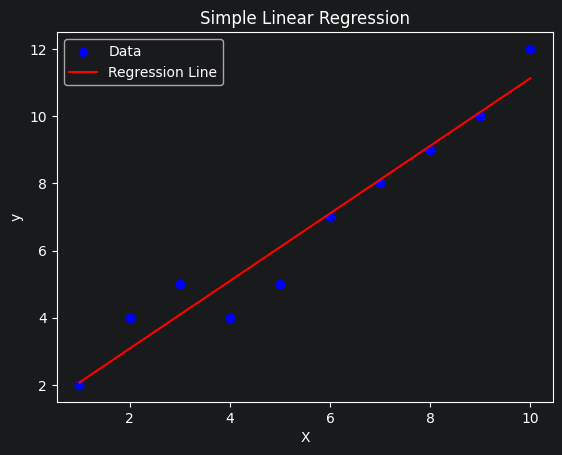

In [4]:
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,5,7,8,9,10,12])

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)


print(f"Simple LR Coefficients: {slr.coefficients_}")
print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()